In [1]:
!pip install transformers


[notice] A new release of pip is available: 23.1.2 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 7.4/7.4 MB 2.8 MB/s eta 0:00:00
     -------------------------------------- 268.8/268.8 kB 3.3 MB/s eta 0:00:00
     -------------------------------------- 152.8/152.8 kB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 3.5/3.5 MB 2.8 MB/s eta 0:00:00
     -------------------------------------- 263.9/263.9 kB 2.0 MB/s eta 0:00:00
     -------------------------------------- 163.8/163.8 kB 2.0 MB/s eta 0:00:00


In [5]:
from datasets import load_dataset

In [6]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from transformers import BertModel, BertTokenizer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

torch.cuda.empty_cache()

# HyperTuning

In [7]:
# Define batch size
BATCH_SIZE = 32
LEARNING_RATE = 0.1

DROPOUT = 0.1

# Training loop
NUM_EPOCHS = 2

# Define number of folds for cross-validation
NUM_FOLDS = 5

# Momentum -> hyperparameter of Stochastic Gradient Descent (SGD) optimizer
MOMENTUM = 0.9

# **Dataset**

In [8]:
# Load the dataset
dataset = load_dataset("csebuetnlp/xnli_bn")

Generating train split:   0%|          | 0/381449 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4895 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2419 [00:00<?, ? examples/s]

In [9]:
# Get the train, test, and validation splits of the dataset
train_dataset = dataset["train"]
test_dataset = dataset["test"]
validation_dataset = dataset["validation"]

# Convert the dataset to DataFrames
train_df = pd.DataFrame(train_dataset)
test_df = pd.DataFrame(test_dataset)
validation_df = pd.DataFrame(validation_dataset)

In [10]:
# Select the required columns
# train_df = train_df[["sentence1", "sentence2", "label"]]
train_df = train_df[["sentence1", "sentence2", "label"]][:6000]
test_df = test_df[["sentence1", "sentence2", "label"]]
validation_df = validation_df[["sentence1", "sentence2", "label"]]

In [11]:
# Drop rows with missing values
train_df.dropna(subset=["sentence1", "sentence2", "label"], inplace=True)
test_df.dropna(subset=["sentence1", "sentence2", "label"], inplace=True)
validation_df.dropna(subset=["sentence1", "sentence2", "label"], inplace=True)

# Drop duplicate rows
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)
validation_df.drop_duplicates(inplace=True)

In [12]:
print(train_df.info())
train_df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence1  6000 non-null   object
 1   sentence2  6000 non-null   object
 2   label      6000 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 187.5+ KB
None


,sentence1,sentence2,label
0,ধারণাগতভাবে ক্রীম স্কিমিং এর দুটি মৌলিক মাত্রা...,পণ্য এবং ভূগোল হচ্ছে ক্রিমের স্কিমিং কাজ।,2
1,আপনি জানেন এই মৌসুমে আর আমার মনে হয় আপনার পর্...,মানুষ যদি স্মরণ করতে পারে তাহলে আপনি নীচের স্ত...,1
2,আমাদের মধ্যে একজন আপনার নির্দেশগুলো পুঙ্খানুপু...,আমার দলের একজন সদস্য আপনার আদেশ পালন করবেন অত্...,1
3,আপনি কিভাবে জানলেন? এই সব তাদের তথ্য আবার.,এই তথ্যটি তাদের।,1
4,হ্যাঁ আমি তোমাকে বলি যদি তুমি কিছু টেনিসের জুত...,টেনিসের জুতার দাম অনেক।,2


In [13]:
print(test_df.info())
test_df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4895 entries, 0 to 4894
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence1  4895 non-null   object
 1   sentence2  4895 non-null   object
 2   label      4895 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 153.0+ KB
None


,sentence1,sentence2,label
0,"আসলে, আমি এমনকি এই বিষয়ে চিন্তাও করিনি, কিন্ত...",আমি তার সাথে আবার কথা বলিনি।,0
1,"আসলে, আমি এমনকি এই বিষয়ে চিন্তাও করিনি, কিন্ত...","আমি এতই ভেঙে পড়েছিলাম যে, আমি আবারও তার সঙ্গে...",1
2,"আসলে, আমি এমনকি এই বিষয়ে চিন্তাও করিনি, কিন্ত...",আমাদের খুব ভালো কথা হয়েছিল।,2
3,"আর আমি ভেবেছিলাম এটা একটা বিশেষ সুযোগ, আর এখনো...","আমি জানতাম না যে, সেই দিন আমিই একমাত্র ব্যক্তি...",2
4,"আর আমি ভেবেছিলাম এটা একটা বিশেষ সুযোগ, আর এখনো...",আমার মনে হয়েছিল যে এএফএফসি বিমান বাহিনীর ক্যা...,1


In [14]:
print(validation_df.info())
validation_df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2419 entries, 0 to 2418
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence1  2419 non-null   object
 1   sentence2  2419 non-null   object
 2   label      2419 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 75.6+ KB
None


,sentence1,sentence2,label
0,"আর সে বললো, মা, আমি বাড়ি।",স্কুলের বাস তাকে নামিয়ে দেওয়ার সঙ্গে সঙ্গে ত...,2
1,"আর সে বললো, মা, আমি বাড়ি।",সে কোন কথা বলেনি.,0
2,"আর সে বললো, মা, আমি বাড়ি।",সে তার মাকে বলেছিল যে সে বাড়ি ফিরে এসেছে।,1
3,"আমি জানতাম না আমি কি জন্য যাচ্ছি বা কিছু, তাই ...",আমি কখনো ওয়াশিংটনে যাইনি তাই যখন আমাকে সেখানে...,2
4,"আমি জানতাম না আমি কি জন্য যাচ্ছি বা কিছু, তাই ...","আমি ঠিক জানতাম যে, ওয়াশিংটনের দিকে যাত্রা করা...",0


In [15]:
label_counts = train_df['label'].value_counts()
print(label_counts)

0    2223
1    2042
2    1735
Name: label, dtype: int64


In [ ]:
# label_0_samples = train_df[train_df['label'] == 0].sample(n=8000, random_state=42)
# label_1_samples = train_df[train_df['label'] == 1].sample(n=8000, random_state=42)
# label_2_samples = train_df[train_df['label'] == 2].sample(n=8000, random_state=42)

# train_df = pd.concat([label_0_samples, label_1_samples, label_2_samples])

# print(train_df.info())
# train_df.head()


In [ ]:
# label_counts = train_df['label'].value_counts()
# # print(label_counts)

In [ ]:
# print((train_df["label"] == 0).head(10))

In [ ]:
# print((train_df["label"] == 1).head())

In [ ]:
# print((train_df["label"] == 2).head(10))

In [16]:
import statistics

max_length_train_sentence1 = max(len(sentence) for sentence in train_df["sentence1"])
max_length_train_sentence2 = max(len(sentence) for sentence in train_df["sentence2"])
max_length_test_sentence1 = max(len(sentence) for sentence in test_df["sentence1"])
max_length_test_sentence2 = max(len(sentence) for sentence in test_df["sentence2"])
max_length_validation_sentence1 = max(len(sentence) for sentence in validation_df["sentence1"])
max_length_validation_sentence2 = max(len(sentence) for sentence in validation_df["sentence2"])


train_lengths_sentence1 = [len(sentence) for sentence in train_df["sentence1"]]
train_avg_length_sentence1 = sum(train_lengths_sentence1) / len(train_lengths_sentence1)
train_median_length_sentence1 = statistics.median(train_lengths_sentence1)

train_lengths_sentence2 = [len(sentence) for sentence in train_df["sentence2"]]
train_avg_length_sentence2 = sum(train_lengths_sentence2) / len(train_lengths_sentence2)
train_median_length_sentence2 = statistics.median(train_lengths_sentence2)

test_lengths_sentence1 = [len(sentence) for sentence in test_df["sentence1"]]
test_avg_length_sentence1 = sum(test_lengths_sentence1) / len(test_lengths_sentence1)
test_median_length_sentence1 = statistics.median(test_lengths_sentence1)

test_lengths_sentence2 = [len(sentence) for sentence in test_df["sentence2"]]
test_avg_length_sentence2 = sum(test_lengths_sentence2) / len(test_lengths_sentence2)
test_median_length_sentence2 = statistics.median(test_lengths_sentence2)

validation_lengths_sentence1 = [len(sentence) for sentence in validation_df["sentence1"]]
validation_avg_length_sentence1 = sum(validation_lengths_sentence1) / len(validation_lengths_sentence1)
validation_median_length_sentence1 = statistics.median(validation_lengths_sentence1)

validation_lengths_sentence2 = [len(sentence) for sentence in validation_df["sentence2"]]
validation_avg_length_sentence2 = sum(validation_lengths_sentence2) / len(validation_lengths_sentence2)
validation_median_length_sentence2 = statistics.median(validation_lengths_sentence2)

print("Maximum length of sentence1 in the train set:", max_length_train_sentence1)
print("Average length of sentence1 in the train set:", train_avg_length_sentence1)
print("Median length of sentence1 in the train set:", train_median_length_sentence1)

print("\nMaximum length of sentence2 in the train set:", max_length_train_sentence2)
print("Average length of sentence2 in the train set:", train_avg_length_sentence2)
print("Median length of sentence2 in the train set:", train_median_length_sentence2)

print("\nMaximum length of sentence1 in the test set:", max_length_test_sentence1)
print("Average length of sentence1 in the test set:", test_avg_length_sentence1)
print("Median length of sentence1 in the test set:", test_median_length_sentence1)

print("\nMaximum length of sentence2 in the test set:", max_length_test_sentence2)
print("Average length of sentence2 in the test set:", test_avg_length_sentence2)
print("Median length of sentence2 in the test set:", test_median_length_sentence2)

print("\nMaximum length of sentence1 in the validation set:", max_length_validation_sentence1)
print("Average length of sentence1 in the validation set:", validation_avg_length_sentence1)
print("Median length of sentence1 in the validation set:", validation_median_length_sentence1)

print("\nMaximum length of sentence2 in the validation set:", max_length_validation_sentence2)
print("Average length of sentence2 in the validation set:", validation_avg_length_sentence2)
print("Median length of sentence2 in the validation set:", validation_median_length_sentence2)

Maximum length of sentence1 in the train set: 638
Average length of sentence1 in the train set: 109.747
Median length of sentence1 in the train set: 96.0

Maximum length of sentence2 in the train set: 252
Average length of sentence2 in the train set: 55.43516666666667
Median length of sentence2 in the train set: 52.0

Maximum length of sentence1 in the test set: 270
Average length of sentence1 in the test set: 104.01307456588356
Median length of sentence1 in the test set: 100

Maximum length of sentence2 in the test set: 199
Average length of sentence2 in the test set: 52.125638406537284
Median length of sentence2 in the test set: 48

Maximum length of sentence1 in the validation set: 249
Average length of sentence1 in the validation set: 103.53162463828028
Median length of sentence1 in the validation set: 100

Maximum length of sentence2 in the validation set: 143
Average length of sentence2 in the validation set: 51.988011575031
Median length of sentence2 in the validation set: 48


# Define BERT classifier model

In [17]:
class BERTClassifier(nn.Module):
    def __init__(self, bert_model, hidden_dim, num_classes):
        super(BERTClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = output['pooler_output']
        pooled_output = self.dropout(pooled_output)
        logits = self.fc(pooled_output)
        return torch.sigmoid(logits)

In [29]:
torch.cuda.empty_cache()

In [30]:
torch.cuda.empty_cache()

**Error**

> Be aware, overflowing tokens are not returned for the setting you have chosen, 
> i.e. sequence pair with longest first truncation strategy. So the returned list will always be empty even if some tokens have been removed.

In [18]:
torch.cuda.empty_cache()

# Set device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the BERT tokenizer
#tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased', add_special_tokens=True, padding='max_length', return_tensors='pt')

# Tokenize and encode the text data for training set
train_encodings = tokenizer(list(train_df["sentence1"]),
                            list(train_df["sentence2"]),
                            truncation=True,
                            padding=True,
                            max_length=128,
                            return_tensors='pt')

# Tokenize and encode the text data for test set
test_encodings = tokenizer(list(test_df["sentence1"]),
                           list(test_df["sentence2"]),
                           truncation=True,
                           padding=True,
                           max_length=128,
                           return_tensors='pt')

# Tokenize and encode the text data for validation set
val_encodings = tokenizer(list(validation_df["sentence1"]),
                          list(validation_df["sentence2"]),
                          truncation=True,
                          padding=True,
                          max_length=128,
                          return_tensors='pt')



# Convert labels to tensor
train_labels = torch.tensor(train_df["label"].values)
test_labels = torch.tensor(test_df["label"].values)
val_labels = torch.tensor(validation_df["label"].values)


# Create PyTorch datasets
train_dataset = TensorDataset(torch.tensor(train_encodings['input_ids']),
                              torch.tensor(train_encodings['attention_mask']),
                              train_labels)
test_dataset = TensorDataset(torch.tensor(test_encodings['input_ids']),
                             torch.tensor(test_encodings['attention_mask']),
                             test_labels)
val_dataset = TensorDataset(torch.tensor(val_encodings['input_ids']),
                            torch.tensor(val_encodings['attention_mask']),
                            val_labels)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

c:\python\python3.9.5\lib\site-packages\huggingface_hub\file_download.py:133: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Acer\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

...

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

In [20]:
# Define the BERT classifier model
bert_model = BertModel.from_pretrained('bert-base-multilingual-cased')
hidden_dim = bert_model.config.hidden_size
num_classes = 3  
model = BERTClassifier(bert_model, hidden_dim, num_classes).to(DEVICE)

# Define the optimizer and loss function
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
criterion = nn.CrossEntropyLoss()

# Freeze the BERT layer
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze the output layer
for param in model.fc.parameters():
    param.requires_grad = True

# Check if the output layer is now trainable
for name, param in model.named_parameters():
    print(name, param.requires_grad)


best_accuracy = 0.0

# Define lists to store metrics for each epoch
train_losses_per_epoch = []
train_accuracies_per_epoch = []
val_losses_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_loader:
        input_ids, attention_mask, labels = batch
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        _, predicted = torch.max(logits, 1)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * input_ids.size(0)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    fold_val_predictions = []
    fold_val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = batch
            input_ids = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(input_ids, attention_mask)
            _, predicted = torch.max(logits, 1)

            loss = criterion(logits, labels)

            val_loss += loss.item() * input_ids.size(0)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            fold_val_predictions.extend(predicted.cpu().numpy())
            fold_val_labels.extend(labels.cpu().numpy())

    val_accuracy = 100 * val_correct / val_total

    train_losses_per_epoch.append(train_loss / train_total)
    train_accuracies_per_epoch.append(train_accuracy)
    val_losses_per_epoch.append(val_loss / val_total)
    val_accuracies_per_epoch.append(val_accuracy)

    print('Epoch: {}/{} | Train Loss: {:.4f} | Train Accuracy: {:.2f}% | Val Loss: {:.4f} | Val Accuracy: {:.2f}%'.format(
        epoch + 1, NUM_EPOCHS, train_loss / train_total, train_accuracy, val_loss / val_total, val_accuracy))

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')

# Calculate performance metrics
average_accuracy = accuracy_score(fold_val_labels, fold_val_predictions)
average_precision = precision_score(fold_val_labels, fold_val_predictions, average='weighted')
average_recall = recall_score(fold_val_labels, fold_val_predictions, average='weighted')
average_f1_score = f1_score(fold_val_labels, fold_val_predictions, average='weighted')

# Print average metrics
print('Average Metrics:')
print('Accuracy: {:.4f} | Precision: {:.4f} | Recall: {:.4f} | F1 Score: {:.4f}'.format(
    average_accuracy, average_precision, average_recall, average_f1_score))



bert.embeddings.word_embeddings.weight False
bert.embeddings.position_embeddings.weight False
bert.embeddings.token_type_embeddings.weight False
bert.embeddings.LayerNorm.weight False
bert.embeddings.LayerNorm.bias False
bert.encoder.layer.0.attention.self.query.weight False
bert.encoder.layer.0.attention.self.query.bias False
bert.encoder.layer.0.attention.self.key.weight False
bert.encoder.layer.0.attention.self.key.bias False
bert.encoder.layer.0.attention.self.value.weight False
bert.encoder.layer.0.attention.self.value.bias False
bert.encoder.layer.0.attention.output.dense.weight False
bert.encoder.layer.0.attention.output.dense.bias False
bert.encoder.layer.0.attention.output.LayerNorm.weight False
bert.encoder.layer.0.attention.output.LayerNorm.bias False
bert.encoder.layer.0.intermediate.dense.weight False
bert.encoder.layer.0.intermediate.dense.bias False
bert.encoder.layer.0.output.dense.weight False
bert.encoder.layer.0.output.dense.bias False
bert.encoder.layer.0.output.Lay

Epoch: 1/2 | Train Loss: 1.1006 | Train Accuracy: 36.25% | Val Loss: 1.0990 | Val Accuracy: 33.44%
Epoch: 2/2 | Train Loss: 1.0960 | Train Accuracy: 35.40% | Val Loss: 1.1095 | Val Accuracy: 33.36%
Average Metrics:
Accuracy: 0.3336 | Precision: 0.2781 | Recall: 0.3336 | F1 Score: 0.1676


c:\python\python3.9.5\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Average Metrics:
Accuracy: 0.3336 | Precision: 0.2781 | Recall: 0.3336 | F1 Score: 0.1676


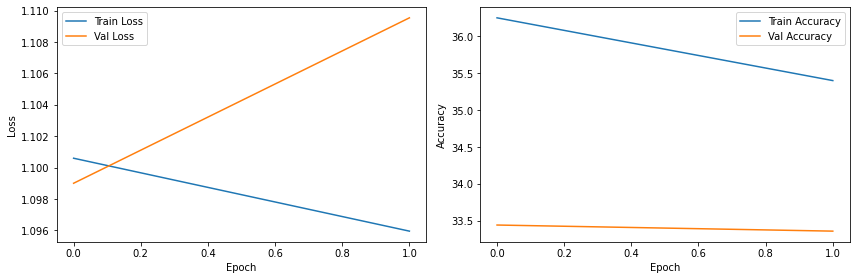

In [21]:
# Print average metrics
print('Average Metrics:')
print('Accuracy: {:.4f} | Precision: {:.4f} | Recall: {:.4f} | F1 Score: {:.4f}'.format(
    average_accuracy, average_precision, average_recall, average_f1_score))

# Plotting the train and validation accuracy and loss graphs
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses_per_epoch, label='Train Loss')
plt.plot(val_losses_per_epoch, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_per_epoch, label='Train Accuracy')
plt.plot(val_accuracies_per_epoch, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Process 2

# Process 3